In [1]:
import numpy as np   
import pandas as pd    
import seaborn as sns
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt   
import matplotlib.style
plt.style.use('classic')
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score,roc_curve,classification_report,confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

## Problem 1

### 1.1. Read the data and do exploratory data analysis. Describe the data briefly. (Check the null values, Data types, shape, EDA). Perform Univariate and Bivariate Analysis.

In [2]:
data = pd.read_csv('cubic_zirconia1.csv')

In [3]:
data.head()

,0,carat,cut,color,clarity,depth,table,x,y,z,price
0,1,0.30,Ideal,E,SI1,62.1,58.0,4.27,4.29,2.66,499
1,2,0.33,Premium,G,IF,60.8,58.0,4.42,4.46,2.70,984
2,3,0.90,Very Good,E,VVS2,62.2,60.0,6.04,6.12,3.78,6289
3,4,0.42,Ideal,F,VS1,61.6,56.0,4.82,4.80,2.96,1082
4,5,0.31,Ideal,F,VVS1,60.4,59.0,4.35,4.43,2.65,779


In [4]:
data = data.drop('0', axis = 1)

In [5]:
data.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.30,Ideal,E,SI1,62.1,58.0,4.27,4.29,2.66,499
1,0.33,Premium,G,IF,60.8,58.0,4.42,4.46,2.70,984
2,0.90,Very Good,E,VVS2,62.2,60.0,6.04,6.12,3.78,6289
3,0.42,Ideal,F,VS1,61.6,56.0,4.82,4.80,2.96,1082
4,0.31,Ideal,F,VVS1,60.4,59.0,4.35,4.43,2.65,779


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26967 entries, 0 to 26966
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    26967 non-null  float64
 1   cut      26967 non-null  object 
 2   color    26967 non-null  object 
 3   clarity  26967 non-null  object 
 4   depth    26270 non-null  float64
 5   table    26967 non-null  float64
 6   x        26967 non-null  float64
 7   y        26967 non-null  float64
 8   z        26967 non-null  float64
 9   price    26967 non-null  int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 2.1+ MB


In [7]:
data.shape

(26967, 10)

In [8]:
data.describe()

,carat,depth,table,x,y,z,price
count,26967.000000,26270.000000,26967.000000,26967.000000,26967.000000,26967.000000,26967.000000
mean,0.798375,61.745147,57.456080,5.729854,5.733569,3.538057,3939.518115
std,0.477745,1.412860,2.232068,1.128516,1.166058,0.720624,4024.864666
min,0.200000,50.800000,49.000000,0.000000,0.000000,0.000000,326.000000
25%,0.400000,61.000000,56.000000,4.710000,4.710000,2.900000,945.000000
50%,0.700000,61.800000,57.000000,5.690000,5.710000,3.520000,2375.000000
75%,1.050000,62.500000,59.000000,6.550000,6.540000,4.040000,5360.000000
max,4.500000,73.600000,79.000000,10.230000,58.900000,31.800000,18818.000000


In [9]:
data.dtypes

carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
x          float64
y          float64
z          float64
price        int64
dtype: object

In [10]:
data.isnull().sum()

carat        0
cut          0
color        0
clarity      0
depth      697
table        0
x            0
y            0
z            0
price        0
dtype: int64

In [11]:
data.median()

carat       0.70
depth      61.80
table      57.00
x           5.69
y           5.71
z           3.52
price    2375.00
dtype: float64

In [12]:
data.depth = data.fillna(data.median())

In [13]:
data.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
price      0
dtype: int64

In [14]:
data['depth'] = data['depth'].astype('float64')

In [15]:
data.duplicated().sum()

38

In [16]:
data.drop_duplicates(inplace=True)

In [17]:
data.duplicated().sum()

0

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000000FE598AE6C8>,
      dtype=object)

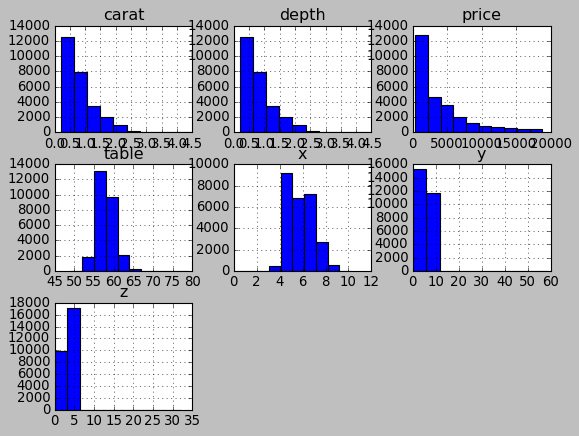

In [18]:
data.hist()

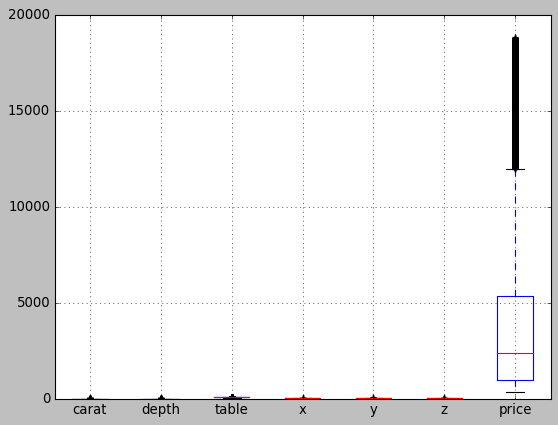

In [19]:
data.boxplot()

In [20]:
def remove_outlier(col):
    sorted(col)
    Q1,Q3=np.percentile(col,[25,75])
    IQR=Q3-Q1
    lower_range= Q1-(1.5 * IQR)
    upper_range= Q3+(1.5 * IQR)
    return lower_range, upper_range

In [21]:
for column in data[['carat','table','x','y','z','price']]:
    lr,ur=remove_outlier(data[column])
    data[column]=np.where(data[column]>ur,ur,data[column])
    data[column]=np.where(data[column]<lr,lr,data[column])

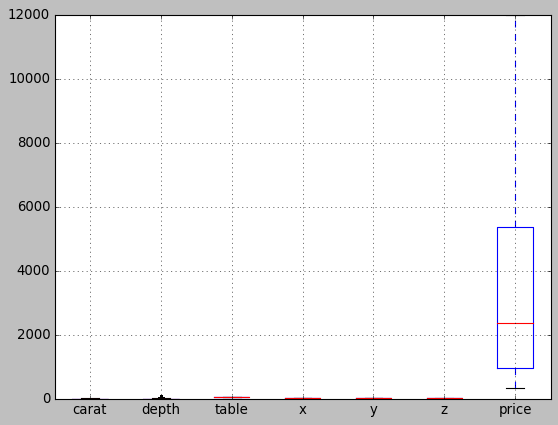

In [22]:
data.boxplot()

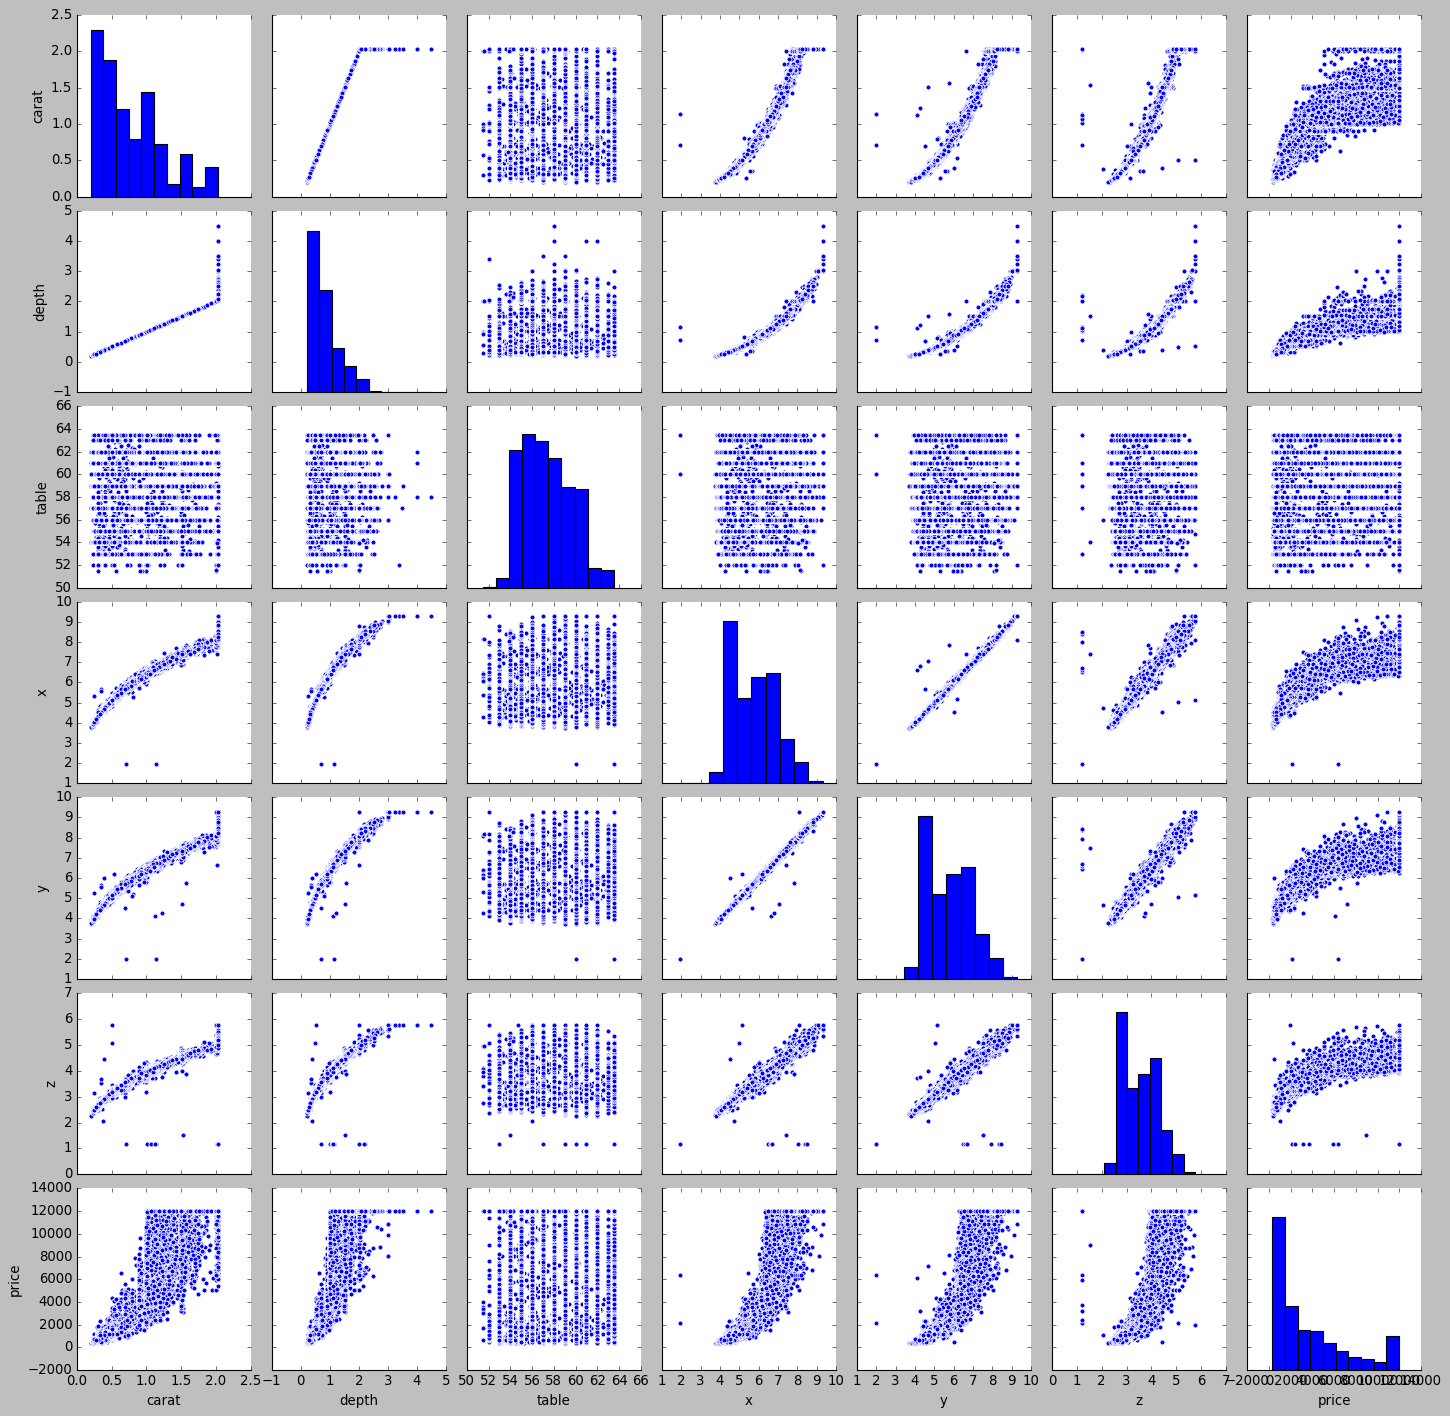

In [23]:
sns.pairplot(data)

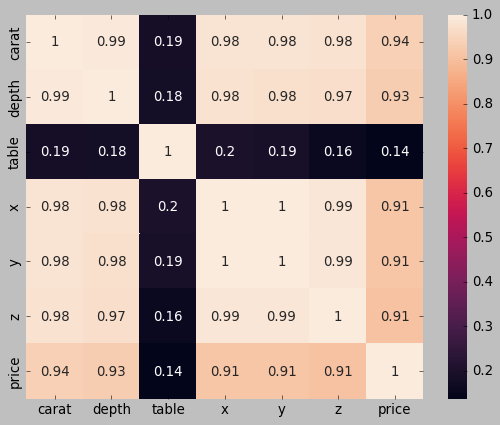

In [24]:
sns.heatmap(data.corr(), annot=True)

In [25]:
data.drop(['depth','x','y','z'], axis = 1,inplace=True)

* The dataset contains null values
* There are three object types, one integer type and six float type features in the dataset
* The dataset contains 26967 observations and 10 features 
* Duplicates in the dataset have been dropped 
* In the histogram plotted Carat,Depth and Price are skewed to the right, while Table and X have a normal distribution. 
* Outliers were found and treated for Price variable
* Pairplot and heat map were drawn for bi-variate analysis
* Depth and Carat had a high correlation, similarily X,Y and Z also had high correlation, thus Depth, Y and Z were dropped to avoid multicollinearity

### 1.2 Impute null values if present, also check for the values which are equal to zero. Do they have any meaning or do we need to change them or drop them? Do you think scaling is necessary in this case?

In [26]:
cat_col = data.select_dtypes(include=['object']).columns
num_col = data.select_dtypes(exclude=['object']).columns
df_cat = data[cat_col]
df_num = data[num_col]

In [27]:
from sklearn import preprocessing
# label_encoder object knows how to understand word labels. 
label_encoder = preprocessing.LabelEncoder() 
# Encode labels in column 'species'. 
data['cut']= label_encoder.fit_transform(data['cut'])
data['color'] = label_encoder.fit_transform(data['color'])
data['clarity'] = label_encoder.fit_transform(data['clarity'])


In [28]:
data.dtypes

carat      float64
cut          int32
color        int32
clarity      int32
table      float64
price      float64
dtype: object

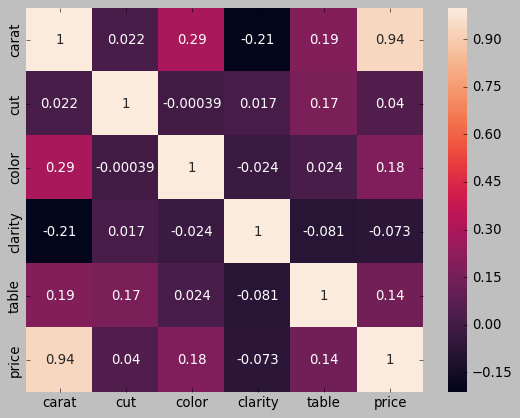

In [29]:
sns.heatmap(data.corr(), annot=True)

* Null values have been imputed using Median 
* values equal to Zero are present in the features X,Y and Z, we need not change them as those features have been dropped 
* Scaling is necessory due to each feature having values of different units, and has been done below using Standard Scaler

### 1.3 Encode the data (having string values) for Modelling. Data Split: Split the data into test and train (70:30). Apply Linear regression. Performance Metrics: Check the performance of Predictions on Train and Test sets using Rsquare, RMSE.

#### <b>Data split<b/>

In [30]:
from sklearn.model_selection import train_test_split
data_train, data_test = train_test_split(data, train_size = 0.7, test_size = 0.3, random_state=1)

In [31]:
data_train.shape

(18850, 6)

In [32]:
data_test.shape

(8079, 6)

In [33]:
scaler = preprocessing.StandardScaler()

In [34]:
import warnings
warnings.filterwarnings("ignore")

data_train[num_col] = scaler.fit_transform(data_train[num_col])
data_test[num_col] = scaler.fit_transform(data_test[num_col])

In [35]:
data_train.head()

,carat,cut,color,clarity,table,price
12108,0.470269,4,0,3,-0.663715,0.413977
10231,-1.155402,4,3,7,-0.663715,-0.954780
4712,-0.071621,1,3,2,2.575422,-0.371181
2548,0.470269,3,3,4,0.724487,0.833267
9710,2.030914,3,3,4,-0.200981,2.379471


In [36]:
y_train = data_train.pop('price')
X_train = data_train

In [37]:
data_train.head()

,carat,cut,color,clarity,table
12108,0.470269,4,0,3,-0.663715
10231,-1.155402,4,3,7,-0.663715
4712,-0.071621,1,3,2,2.575422
2548,0.470269,3,3,4,0.724487
9710,2.030914,3,3,4,-0.200981


#### Linear Regression using Sklearn

In [38]:
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

#### Co-efficient for features

In [39]:

for idx, col_name in enumerate(X_train.columns):
    print('The coefficient for {} is {}'.format(col_name, regression_model.coef_[idx]))

The coefficient for carat is 1.005275059558169
The coefficient for cut is 0.020827572506958675
The coefficient for color is -0.06488669495989932
The coefficient for clarity is 0.07636181022336798
The coefficient for table is -0.04331608578239498


#### Intercept 

In [40]:

intercept = regression_model.intercept_

print("The intercept for our model is {}".format(intercept))

The intercept for our model is -0.17728187712163687


#### R-squared

In [41]:
regression_model.score(X_train, y_train)

0.908385900375751

#### RMSE

In [42]:
mse = np.mean((regression_model.predict(X_train)-y_train)**2)

In [43]:
import math

math.sqrt(mse)

0.3026782113470496

#### Linear regression using Statsmodels

In [44]:
import statsmodels.api as sm  
X_train = sm.add_constant(X_train)
lm = sm.OLS(y_train,X_train).fit()

#Summary of linear model
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.908
Model:                            OLS   Adj. R-squared:                  0.908
Method:                 Least Squares   F-statistic:                 3.737e+04
Date:                Sun, 19 Apr 2020   Prob (F-statistic):               0.00
Time:                        11:49:55   Log-Likelihood:                -4219.6
No. Observations:               18850   AIC:                             8451.
Df Residuals:                   18844   BIC:                             8498.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1773      0.008    -21.179      0.0

* Dataset containing string values have been encoded using Label Encoder 
* The Dataset has been split into train and test in 70:30 ratio and Linear Regression was applied using both Statsmodels and Sklearn
* the following is the Linear Regression Equation for Train set : <b>price = -0.18 + 1carat + 0.02cut - 0.06color + 0.08clarity - 0.04table</b>
* When carat increases by 1 unit, price increases by 1 unit, keeping all other predictors constant. similarly, when cut increases by 1 unit, price increases by 0.02 units, keeping all other predictors constant. 
* There are also some negative co-efficient values, for instance, color has its corresponding co-efficient as -0.06. This implies, when the color increases by 1 unit, the price decreases by 0.06 units, keeping all other predictors constant. 
* The R-squared and adjusted R-squared are both at 91% implying the model has not been overfitted or underfitted and 91% of the variation in price is explained by the predictors in the model
* The RMSE is at 30% indicating a good fit 

In [45]:
y_test = data_test.pop('price')
X_test = data_test

#### Linear Regression using Sklearn

In [46]:
regression_model = LinearRegression()
regression_model.fit(X_test, y_test)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

#### Coefficient for features 

In [47]:
for idx, col_name in enumerate(X_test.columns):
    print('The coefficient for {} is {}'.format(col_name, regression_model.coef_[idx]))

The coefficient for carat is 1.0021668088676963
The coefficient for cut is 0.023232239516827433
The coefficient for color is -0.06623564450038974
The coefficient for clarity is 0.07814659062981767
The coefficient for table is -0.03366032367739269


#### Intercept 

In [48]:
intercept = regression_model.intercept_

print("The intercept for our model is {}".format(intercept))

The intercept for our model is -0.1857009835083616


#### R-squared

In [49]:
regression_model.score(X_test, y_test)

0.902668342666347

#### RMSE

In [50]:
mse = np.mean((regression_model.predict(X_test)-y_test)**2)

In [51]:
import math

math.sqrt(mse)

0.3119802194589473

#### Linear Regression using Statsmodels

In [52]:
X_test = sm.add_constant(X_test)
lm = sm.OLS(y_test,X_test).fit()

#Summary of linear model
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                 1.497e+04
Date:                Sun, 19 Apr 2020   Prob (F-statistic):               0.00
Time:                        11:50:02   Log-Likelihood:                -2053.1
No. Observations:                8079   AIC:                             4118.
Df Residuals:                    8073   BIC:                             4160.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1857      0.013    -13.856      0.0

* the following is the Linear Regression Equation for Test set : <b>price = -0.185 + 1carat + 0.02cut - 0.07color + 0.07clarity - 0.03table</b>
* When carat increases by 1 unit, price increases by 1 unit, keeping all other predictors constant. similarly, when cut increases by 1 unit, price increases by 0.02 units, keeping all other predictors constant. 
* There are also some negative co-efficient values, for instance, color has its corresponding co-efficient as -0.07. This implies, when the color increases by 1 unit, the price decreases by 0.07 units, keeping all other predictors constant. 
* The R-squared and adjusted R-squared are both at 90% implying the model has not been overfitted or underfitted and 90% of the variation in price is explained by the predictors in the model
* The RMSE is at 31% indicating a good fit 

In [53]:
from sklearn.feature_selection import RFE 
model = LinearRegression()
rfe = RFE(model, 1)
fit = rfe.fit(X_test, y_test)
print("Num Features: %s" % (fit.n_features_))
print("Selected Features: %s" % (fit.support_))
print("Feature Ranking: %s" % (fit.ranking_))

Num Features: 1
Selected Features: [False  True False False False False]
Feature Ranking: [6 1 5 3 2 4]


* To identify the top five important attributes Feature Selection using Recursive Feature Elimination (RFE) was done and the following are the top five Features 
 1.Carat
 2.Clarity
 3.Color
 4.Table
 5.Cut

## Problem 2

### 2.1 Data Ingestion: Read the dataset. Do the descriptive statistics and do null value condition check, write an inference on it. Perform Univariate and Bivariate Analysis. Do exploratory data analysis.

In [54]:
df = pd.read_csv('Holiday_Package1.csv')

In [55]:
df.head()

,0,Holliday_Package,Salary,age,educ,no_young_children,no_older_children,foreign
0,1,no,48412,30,8,1,1,no
1,2,yes,37207,45,8,0,1,no
2,3,no,58022,46,9,0,0,no
3,4,no,66503,31,11,2,0,no
4,5,no,66734,44,12,0,2,no


In [56]:
df = df.drop('0',axis=1)
df.head()

,Holliday_Package,Salary,age,educ,no_young_children,no_older_children,foreign
0,no,48412,30,8,1,1,no
1,yes,37207,45,8,0,1,no
2,no,58022,46,9,0,0,no
3,no,66503,31,11,2,0,no
4,no,66734,44,12,0,2,no


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 872 entries, 0 to 871
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Holliday_Package   872 non-null    object
 1   Salary             872 non-null    int64 
 2   age                872 non-null    int64 
 3   educ               872 non-null    int64 
 4   no_young_children  872 non-null    int64 
 5   no_older_children  872 non-null    int64 
 6   foreign            872 non-null    object
dtypes: int64(5), object(2)
memory usage: 47.8+ KB


In [58]:
df.describe()

,Salary,age,educ,no_young_children,no_older_children
count,872.000000,872.000000,872.000000,872.000000,872.000000
mean,47729.172018,39.955275,9.307339,0.311927,0.982798
std,23418.668531,10.551675,3.036259,0.612870,1.086786
min,1322.000000,20.000000,1.000000,0.000000,0.000000
25%,35324.000000,32.000000,8.000000,0.000000,0.000000
50%,41903.500000,39.000000,9.000000,0.000000,1.000000
75%,53469.500000,48.000000,12.000000,0.000000,2.000000
max,236961.000000,62.000000,21.000000,3.000000,6.000000


In [59]:
df.isnull().sum()

Holliday_Package     0
Salary               0
age                  0
educ                 0
no_young_children    0
no_older_children    0
foreign              0
dtype: int64

In [60]:
dups = df.duplicated()
print('Number of duplicate rows = %d' % (dups.sum()))
print(df.shape)

Number of duplicate rows = 0
(872, 7)


In [61]:
for feature in df.columns: 
    if df[feature].dtype == 'object': 
        print(feature)
        print(df[feature].value_counts())
        print('\n')

Holliday_Package
no     471
yes    401
Name: Holliday_Package, dtype: int64


foreign
no     656
yes    216
Name: foreign, dtype: int64




In [62]:
df.Holliday_Package.value_counts(normalize=True)

no     0.540138
yes    0.459862
Name: Holliday_Package, dtype: float64

* The Dataset contains 872 observations and 7 features out of which five are integer type and two are object type
* There are no null values or duplicates in the dataset 
* 46% of the employees have opted Yes for the Holliday Package while 54% have opted no


#### Mean
* Salary: 47729.17
* Age: 40
* Educ: 9.3
* no_young_children: 0.3
* no_old_children: 0.9

#### Median 
* Salary: 41903.5
* Age: 39
* Educ: 9
* no_young_children: 0
* no_old_children: 1

In [63]:
df.mode()

,Holliday_Package,Salary,age,educ,no_young_children,no_older_children,foreign
0,no,32197,44.0,8.0,0.0,0.0,no
1,NaN,33357,NaN,NaN,NaN,NaN,NaN
2,NaN,35341,NaN,NaN,NaN,NaN,NaN
3,NaN,36976,NaN,NaN,NaN,NaN,NaN
4,NaN,39460,NaN,NaN,NaN,NaN,NaN
5,NaN,40270,NaN,NaN,NaN,NaN,NaN
6,NaN,44280,NaN,NaN,NaN,NaN,NaN
7,NaN,46195,NaN,NaN,NaN,NaN,NaN


#### Mode
* Salary: 32197
* Age: 44
* educ: 8
* no_young_children: 0
* no_old_children: 0

* The most common age of employee is 44
* Most of the employees do not have children, if they do they are all old children
* The salary ranges from 30000 to 50000 
* The employees have atleast 9 years of education 

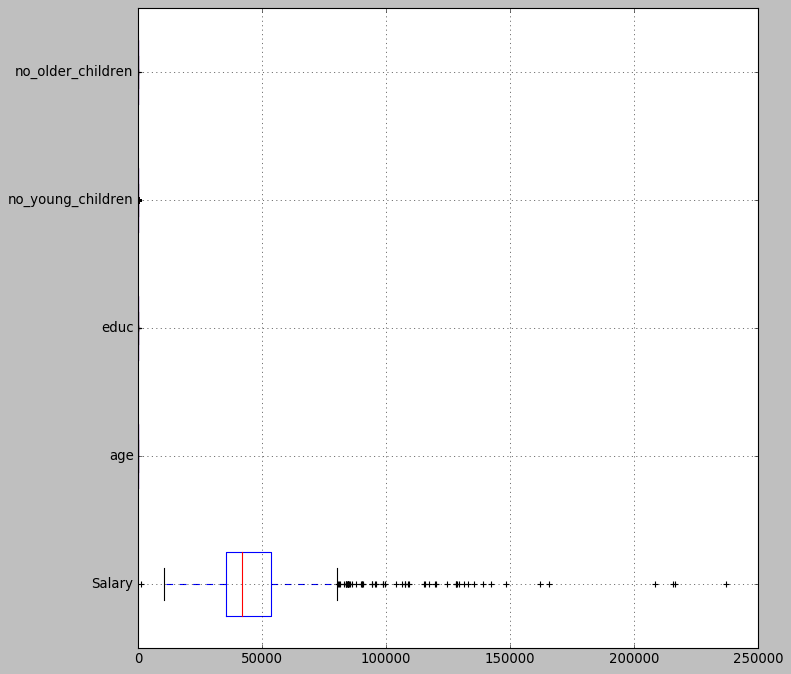

In [64]:
plt.figure(figsize=(10,10))
df.boxplot(vert=0)

* Although there are outliers present, they are not treated since the Median and mode are fairly close to each other

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000000FE649FB7C8>,
      dtype=object)

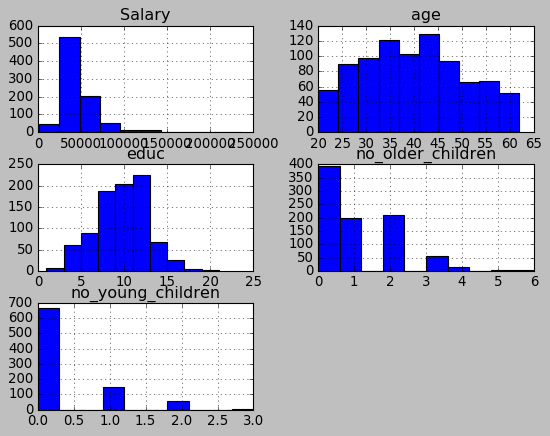

In [65]:
df.hist()

* Salary is rightly skewed
* Age and Educ have a roughly Normal distribution 

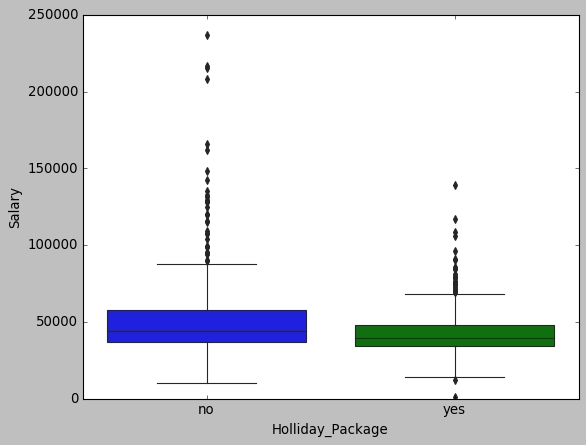

In [66]:
sns.boxplot(df['Holliday_Package'],df['Salary'])

* Employees with higher salary have opted No 

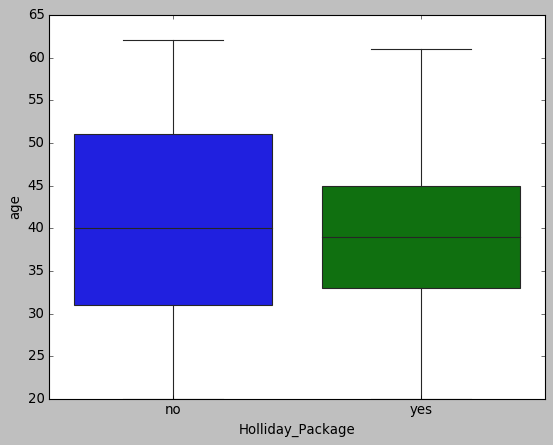

In [67]:
sns.boxplot(df['Holliday_Package'],df['age'])

* Age doesn't seem to be affecting Holliday package

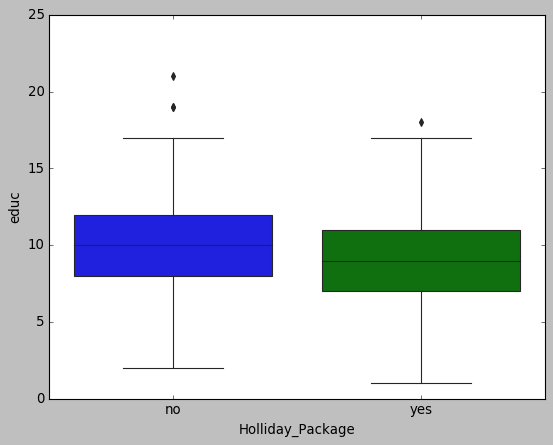

In [68]:
sns.boxplot(df['Holliday_Package'],df['educ'])

* Education is also not a factor affecting Holliday Package

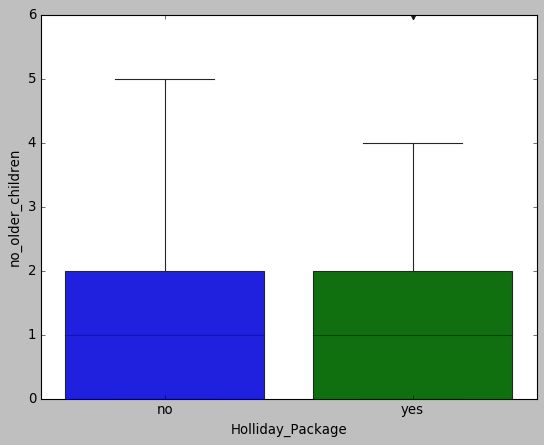

In [69]:
sns.boxplot(df['Holliday_Package'],df['no_older_children'])

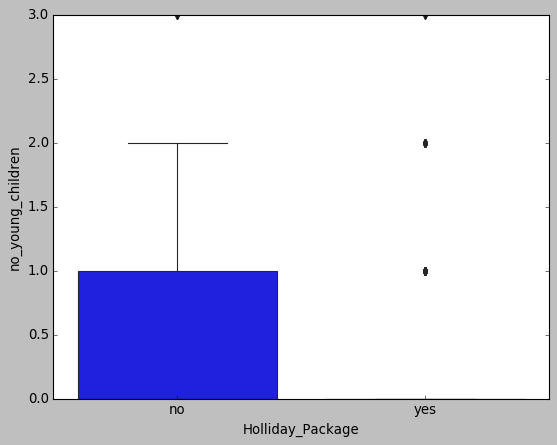

In [70]:
sns.boxplot(df['Holliday_Package'],df['no_young_children'])

* Both young or old children have no effect on the target variable 

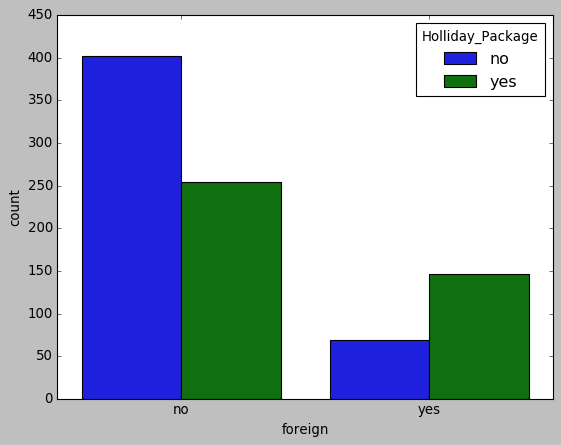

In [71]:
sns.countplot(df['foreign'],hue=df['Holliday_Package'])

* The ratio of non-foreigners are high compared to foreigners
* most of the non Foreigners have opted no while there are some who have opted yes 
* Most of the Foreigners have opted yes while the rest has opted no 

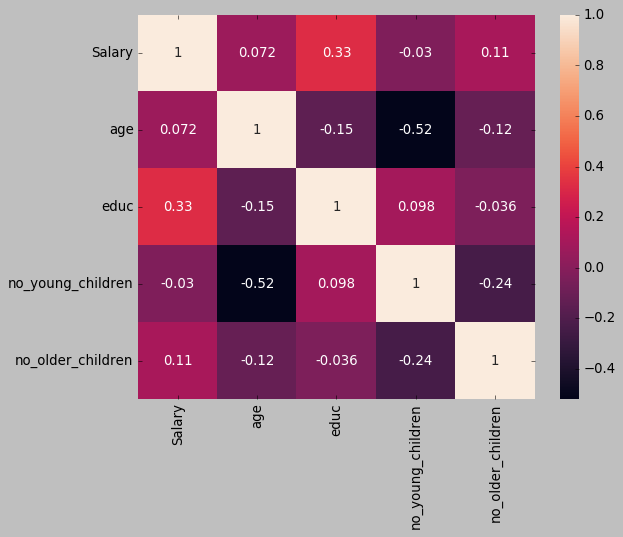

In [72]:
sns.heatmap(df.corr(), annot=True)

* None of the Features have high correlation

### 2.2 Do not scale the data. Encode the data (having string values) for Modelling. Data Split: Split the data into train and test (70:30). Apply Logistic Regression and LDA (linear discriminant analysis).

### 2.3 Performance Metrics: Check the performance of Predictions on Train and Test sets using Accuracy, Confusion Matrix, Plot ROC curve and get ROC_AUC score for each model Final Model: Compare Both the models and write inference which model is best/optimized.

In [73]:
for feature in df.columns: 
    if df[feature].dtype == 'object': 
        print('\n')
        print('feature:',feature)
        print(pd.Categorical(df[feature].unique()))
        print(pd.Categorical(df[feature].unique()).codes)
        df[feature] = pd.Categorical(df[feature]).codes



feature: Holliday_Package
[no, yes]
Categories (2, object): [no, yes]
[0 1]


feature: foreign
[no, yes]
Categories (2, object): [no, yes]
[0 1]


* Data having String Values have been encoded into 0s and 1s wherin no means 0 and Yes means 1 

In [74]:
X = df.drop('Holliday_Package', axis=1) 
y = df[['Holliday_Package']]

In [75]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30 , random_state=1)

### Logistic Regression 

In [76]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [77]:
ytrain_predict = model.predict(X_train)
ytest_predict = model.predict(X_test)

### Accuracy for Training set

In [78]:
lg_acc_train=model.score(X_train, y_train)

* The Accuracy of the model is 51% 

### AUC and ROC for Training set 

AUC: 0.567


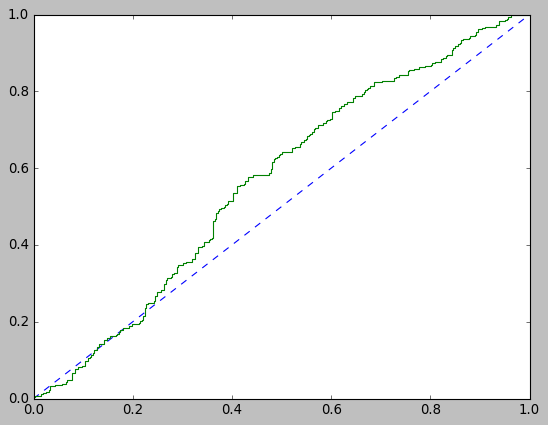

In [79]:
probs = model.predict_proba(X_train)
probs = probs[:, 1]
lg_auc_train = roc_auc_score(y_train, probs)
print('AUC: %.3f' % lg_auc_train)
train_fpr, train_tpr, train_thresholds = roc_curve(y_train, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(train_fpr, train_tpr)

* AUC is 57% for training data 

### Accuracy for Test data 

In [80]:
lg_acc_test=model.score(X_test, y_test)

* Accuracy for test data is 53% 

### AUC and ROC for Test data 

AUC: 0.627


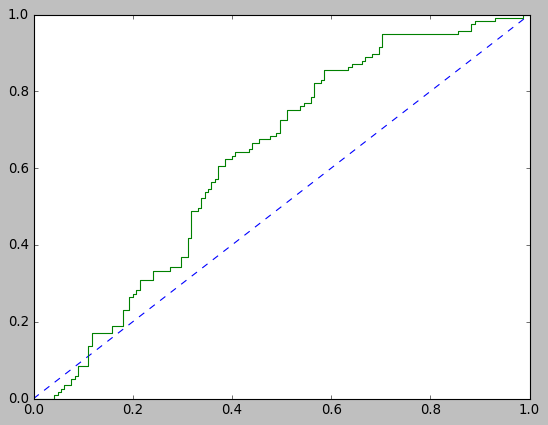

In [81]:
probs = model.predict_proba(X_test)
probs = probs[:, 1]
lg_auc_test = roc_auc_score(y_test, probs)
print('AUC: %.3f' % lg_auc_test)
test_fpr, test_tpr, test_thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(test_fpr, test_tpr)

* AUC for test data is 63% 

### Confusion Matric and classification Report for Training data 

In [82]:
confusion_matrix(y_train, ytrain_predict)

array([[294,  32],
       [261,  23]], dtype=int64)

In [83]:
print(classification_report(y_train, ytrain_predict))

              precision    recall  f1-score   support

           0       0.53      0.90      0.67       326
           1       0.42      0.08      0.14       284

    accuracy                           0.52       610
   macro avg       0.47      0.49      0.40       610
weighted avg       0.48      0.52      0.42       610



In [84]:
lg_metrics=classification_report(y_train, ytrain_predict,output_dict=True)
df=pd.DataFrame(lg_metrics).transpose()
lg_train_precision=round(df.loc["1"][0],2)
lg_train_recall=round(df.loc["1"][1],2)
print ('lg_train_precision ',lg_train_precision)
print ('lg_train_recall ',lg_train_recall)

lg_train_precision  0.42
lg_train_recall  0.08


* Precision and Recall are both low making the model weak 

### Confusion Matrix and Classification Report for Test data 

In [85]:
cnf_matrix=confusion_matrix(y_test, ytest_predict)
cnf_matrix

array([[129,  16],
       [107,  10]], dtype=int64)

In [86]:
print(classification_report(y_test, ytest_predict))

              precision    recall  f1-score   support

           0       0.55      0.89      0.68       145
           1       0.38      0.09      0.14       117

    accuracy                           0.53       262
   macro avg       0.47      0.49      0.41       262
weighted avg       0.47      0.53      0.44       262



In [87]:
lg_metrics=classification_report(y_test, ytest_predict,output_dict=True)
df=pd.DataFrame(lg_metrics).transpose()
lg_test_precision=round(df.loc["1"][0],2)
lg_test_recall=round(df.loc["1"][1],2)
print ('lg_test_precision ',lg_test_precision)
print ('lg_test_recall ',lg_test_recall)

lg_test_precision  0.38
lg_test_recall  0.09


* Precision and Recall are low for test data

## Linear Discriminant Analysis 

In [88]:
clf = LinearDiscriminantAnalysis()
model=clf.fit(X,y)
model

LinearDiscriminantAnalysis(n_components=None, priors=None, shrinkage=None,
                           solver='svd', store_covariance=False, tol=0.0001)

### Confusion Matrix and Classification Report

In [90]:
confusion_matrix(y, pred_class)

array([[360, 111],
       [183, 218]], dtype=int64)

In [91]:
print(classification_report(y, pred_class))

              precision    recall  f1-score   support

           0       0.66      0.76      0.71       471
           1       0.66      0.54      0.60       401

    accuracy                           0.66       872
   macro avg       0.66      0.65      0.65       872
weighted avg       0.66      0.66      0.66       872



In [92]:
lda_metrics=classification_report(y, pred_class,output_dict=True)
df=pd.DataFrame(lda_metrics).transpose()
lda_precision=round(df.loc["1"][0],2)
lda_recall=round(df.loc["1"][1],2)
print ('lda_precision ',lda_precision)
print ('lda_recall ',lda_recall)

lda_precision  0.66
lda_recall  0.54


* Precision and Recall are moderate 

### Accuracy 

In [93]:
lda_acc=model.score(X,y)

* Accuracy is at 66% 

In [94]:
index=['Accuracy', 'Recall','Precision']
data = pd.DataFrame({'lg Train':[lg_acc_train,lg_train_recall,lg_train_precision],
        'lg Test':[lg_acc_test,lg_test_recall,lg_test_precision],
        'lda':[lda_acc,lda_recall,lda_precision]},index=index)
round(data,2)

,lg Train,lg Test,lda
Accuracy,0.52,0.53,0.66
Recall,0.08,0.09,0.54
Precision,0.42,0.38,0.66


* LDA's performance measures are higher than that of Logistic Regression thus LDA is best optimized fo rthis dataset 

In [95]:
from sklearn.feature_selection import RFE 
model = LogisticRegression()
rfe = RFE(model, 1)
fit = rfe.fit(X_train, y_train)
print("Num Features: %s" % (fit.n_features_))
print("Selected Features: %s" % (fit.support_))
print("Feature Ranking: %s" % (fit.ranking_))

Num Features: 1
Selected Features: [False False False False False  True]
Feature Ranking: [6 4 5 2 3 1]


* To identify the top five important attributes Feature Selection using Recursive Feature Elimination (RFE) was done and the following are the top five Features 1.Foreign 2.no_young_children 3.no_old_children 4.Age 5.Educ